## Deep Neural Network with Hidden Networks

In [53]:
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np


# data sets download from https://www.kaggle.com/datasets/tongpython/cat-and-dog
base = "../../dataset/catvdog"
train_dir = Path(base+ "/training_set")
test_dir = Path(base + "/test_set")


IMAGE_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def explain_data_sets(root):
    widths, heights = [],[]
    modes, per_class= Counter(), Counter()
    bad = []
    
    for p in root.rglob("*"):
        if p.suffix.lower() not in IMAGE_EXT:
            continue
        try:
            with Image.open(p) as im:
                w,h = im.size
                widths.append(w)
                heights.append(h)
                modes[im.mode] += 1
            per_class[p.parent.name] += 1
        except Exception as e:
            bad.append((p.name, repr(e)))
    
    widths = np.array(widths)
    heights = np.array(heights)
    ratios = widths/heights

    
    print(f"total readble:{len(widths)}, total underadable:{len(bad)}")
    print("ureadable:", len(bad), bad[:5])
    print("per_class:", per_class)
    print("modes:", modes)
    stats("widths", widths)
    stats("heights", heights)
    stats("ratios", ratios)
    
    print("distinct sizes", len(set(zip(widths.tolist(), heights.tolist()))))
    print("extreme ratios", int(((ratios < 0.5) | (ratios > 2.0)).sum()))


def stats(name, a):
    print(f"name={name:8},min={a.min():.2f},p10={np.percentile(a,10):.2f} " + 
         f"median={np.median(a):.2f}, max={a.max():.2f}")



explain_data_sets(train_dir)
explain_data_sets(test_dir)


total readble:8005, total underadable:0
ureadable: 0 []
per_class: Counter({'dogs': 4005, 'cats': 4000})
modes: Counter({'RGB': 8005})
name=widths  ,min=57.00,p10=240.00 median=445.00, max=1050.00
name=heights ,min=41.00,p10=225.00 median=374.00, max=768.00
name=ratios  ,min=0.38,p10=0.75 median=1.27, max=2.84
distinct sizes 3529
extreme ratios 75
total readble:2023, total underadable:0
ureadable: 0 []
per_class: Counter({'dogs': 1012, 'cats': 1011})
modes: Counter({'RGB': 2023})
name=widths  ,min=59.00,p10=242.00 median=448.00, max=500.00
name=heights ,min=33.00,p10=224.00 median=374.00, max=500.00
name=ratios  ,min=0.42,p10=0.75 median=1.28, max=5.91
distinct sizes 1139
extreme ratios 12


In [54]:
SIZE = 64
CLASSES = ["cats", "dogs"]
LABEL_OF = {c: i for i, c in enumerate(CLASSES)}

def load_data_set(root):
    root = Path(root)
    images, labels = [], []

    for p in sorted(root.rglob("*")):
        if p.suffix.lower() not in IMAGE_EXT:
            # print(f" name:{p.name}")
            continue
        if p.parent.name not in LABEL_OF:
            continue

        with Image.open(p) as im:
            im = im.convert("RGB").resize((SIZE,SIZE), Image.BILINEAR)

        images.append(np.asarray(im, dtype=np.uint8))
        labels.append(LABEL_OF[p.parent.name])

    X = np.stack(images)
    Y = np.array(labels, dtype=np.int64)

    return X, Y
    

In [55]:
def flatten(X):
    return X.reshape(X.shape[0],-1).T / 255


def prepare_data_set():
    X_train_orig_set, Y_train_orig_set = load_data_set(train_dir)
    X_test_orig_set, Y_test_orig_set = load_data_set(test_dir)
    
    # print(X_train_orig_set.shape, Y_train_orig_set.shape)
    # print(X_test_orig_set.shape, Y_test_orig_set.shape)
    
    # Reshuffle the datasets  (since we ordered it previously)
    rng = np.random.default_rng(0)
    perm = rng.permutation(len(Y_train_orig_set))
    permtest = rng.permutation(len(Y_test_orig_set))
    
    X_train_orig_set, Y_train_orig_set = X_train_orig_set[perm], Y_train_orig_set[perm]
    X_test_orig_set, Y_test_orig_set = X_test_orig_set[permtest], Y_test_orig_set[permtest]

    # Flatten the data sets for the model.
    X_train = flatten(X_train_orig_set)
    X_test = flatten(X_test_orig_set)
    
    Y_train = Y_train_orig_set.reshape(1, -1)
    Y_test = Y_test_orig_set.reshape(1,-1)

    datasets =  {
        "X_train": X_train,
        "X_test": X_test,
        "Y_train": Y_train,
        "Y_test": Y_test,
        "X_train_orig_set": X_train_orig_set,
        "Y_train_orig_set": Y_train_orig_set,
        "X_test_orig_set": X_test_orig_set,
        "Y_test_orig_set": Y_test_orig_set
    }
    return datasets
    

In [56]:
datasets = prepare_data_set()

Y_train = datasets["Y_train"]
X_train = datasets ["X_train"]
X_test = datasets["X_test"]
Y_test = datasets["Y_test"]
X_test_orig_set = datasets["X_test_orig_set"]
X_train_orig_set = datasets["X_train_orig_set"]
assert X_train.shape == (SIZE * SIZE * 3, Y_train.shape[1])
assert set(np.unique(Y_train)) <= {0,1}


In [100]:
import numpy as np


def relu(Z):
    a = np.maximum(0,Z)
    return a

def sigmoid(Z):
    a = 1 / (1 + np.exp(-Z))
    return a


In [178]:
def initialize_parameters (layer_dims):
    L = len(layer_dims) 
    # print(f"Len Param {len(layer_dims)}")
    np.random.seed(7)
    parameters = {}
    for l in range (1, L): # start from layer 1, we don't have W0 or b0, we have weights and bias from layer 1
        # print (f"l={l}")
        parameters["W"+ str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2 / layer_dims[l-1])
        parameters["b" + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters

In [169]:
from typing import NamedTuple
class ActivationCache (NamedTuple):
    Z: np.ndarray

def activate(Z, activation_function):
    cache = ActivationCache(Z = Z)
    if (activation_function == "relu"):
        A = relu(Z)
    elif (activation_function == "sigmoid"):
        A = sigmoid(Z)
    
    return A, cache

In [170]:
class PropagateCache (NamedTuple):
    W: np.ndarray
    Aprev: np.ndarray
    b: np.ndarray

def propagate(W, Aprev, b):
  cache = PropagateCache(W=W, b=b, Aprev=Aprev)
  Z = np.dot(W,Aprev) + b
  return Z, cache

class ForwardCache (NamedTuple):
    PropagateCache: PropagateCache
    ActivationCache: ActivationCache

def forward_pass(X, parameters):
    # find the number of layers from the initialized parameters
    L = len(parameters) // 2

    # print(f"Len Layer: {L}")
    cache = [] # we need this later for backward propagation
    Aprev = X # initial assignment to A0
    for l in range(0,L):
        # here we calcualte Zl     
        Zl, pc = propagate(parameters["W"+str(l+1)], Aprev, parameters["b"+str(l+1)])
        # here we calculate Al (it should be started from 1 by the loop)
        if (l == (L-1)): # for output layer, we use sigmoid
            Aprev, ac= activate(Zl, "sigmoid")
        else:
            Aprev, ac= activate(Zl, "relu")
        forward_cache = ForwardCache(PropagateCache = pc, ActivationCache=ac) 
        cache.append(forward_cache)
    output = Aprev
    # print(f"Len in forward: {len(cache)} {len(parameters)} ")
    return output, cache

In [109]:
def AL_derivative(AL,Y):
    # since our cost function uses binary cross-entropy, then:
    # -(Y/A) + ((1-Y)/ (1-A))
    dAL = -(np.divide(Y,AL)) + np.divide((1-Y), (1-AL))
    return dAL


# In backward, we will pass the forward_pass cache, from which we can extract
# the activation cache.
# ReLU backward function logic:
# if Z <= 0 return 0; else return dA
# Note: We must use an element-wise condition because Z and dA are arrays.
# Since this is used in hidden layers, we accept dA from the backward sequence
# and apply the chain rule.
def relu_backward(dA, activation_cache):
    Z = activation_cache.Z
    dZ = np.array(dA, copy=True) # Create a copy to safely modify the array
    # When Z <= 0, the local derivative is 0, so set dZ to 0 (element-wise)
    dZ[Z <= 0] = 0
    return dZ

# Sigmoid backward function logic:
# First calculate the local derivative of the activation function with respect to Z:
# dLocal = A * (1 - A)
# then apply the chain rule with the incoming gradient (dA) to compute dZ
def sigmoid_backward(dA, activation_cache):
    Z = activation_cache.Z

    # Get the original activation output matrix 'A'
    A = sigmoid(Z)
    
    # Calculate the local derivative and apply the chain rule
    dZLocal = A * (1 - A)
    dZ = dA * dZLocal

    return dZ
    
# Propagate backward: calculate the derivative of  Z = W . Aprev + b
def propagate_backward(dZ, Aprev, W):
    m = Aprev.shape[1]
    dW = 1/m * np.dot(dZ, Aprev.T)
    # sum horizontally across the batch dimension, keeping it as a column vector
    # because we only have 1 bias per neurons
    db = 1/m * np.sum(dZ, axis=1, keepdims=True)
    dAprev = np.dot(W.T, dZ)
    return dW, db, dAprev
    

In [138]:
def backward_pass(AL, Y, caches):

    grads = {}
    L = len(caches)
    current_layer_cache = caches[L-1]
    current_layer_W = current_layer_cache.PropagateCache.W
    current_layer_Aprev = current_layer_cache.PropagateCache.Aprev
    
    # calculate the dAL
    dAL = AL_derivative(AL, Y)

    # get the dZ for outer/output layer
    dZ = sigmoid_backward(dAL, current_layer_cache.ActivationCache)
    dW,db, dAprev = propagate_backward(dZ, current_layer_Aprev, current_layer_W )
    grads["dW"+str(L)] = dW
    grads["db"+str(L)] = db

    # print(f"l in backward = {L}")
    
    for l in reversed (range (L-1)):
        current_layer_cache = caches[l]
        current_layer_W = current_layer_cache.PropagateCache.W
        current_layer_Aprev = current_layer_cache.PropagateCache.Aprev
        dZ = relu_backward(dAprev, current_layer_cache.ActivationCache)
        dW,db,dAprev = propagate_backward(dZ, current_layer_Aprev, current_layer_W)
        # print(f"l in backward = {l+1}")
        grads["dW" + str(l+1)] = dW
        grads["db" + str(l+1)] = db
    

    # print(f"grads: {len(grads)}")

    # for l in range (1, L+1):
    #     print(f"grads: {grads["dW" + str(l)].shape}")
    
    return grads
    
    
    

In [155]:
def calculate_cost(AL,Y):
    m = AL.shape[1]
    cost =  -(1./m) * np.sum((np.dot(Y,np.log(AL).T) + np.dot(1-Y, np.log(1-AL).T)))
    # make sure the output not a a 0-dimensional array/scalar
    # eg 2D array (matrix) number: [[24]] => become 24.
    res = np.squeeze(cost)
    return res

In [173]:
def update_parameter(parameters, grads, learning_rate):

    # floor divide by 2 because each layer has both a 'W' and a 'b'
    L = len(parameters) // 2
    
    for l in range (0, L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - (learning_rate * grads["dW"+str(l+1)])
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - (learning_rate * grads["db"+str(l+1)])

    assert len(grads) == len(parameters)
    return parameters

In [175]:
# classify will apply the propagation with the given parameters
# and return the classification as 1 or 0
def classify(X,parameters):
    output, _ = forward_pass(X,parameters)
    return (output > 0.5).astype(int)


def dnn_model(X_train, Y_train, X_test, Y_test, layers_dims, iteration=2500, learning_rate=0.0075, print_cost=False):
    parameters = initialize_parameters(layers_dims)
    costs = []
    for i in range(1,iteration+1):
        AL, cache = forward_pass(X_train, parameters)
        cost = calculate_cost(AL,Y_train)
        grads = backward_pass(AL, Y_train, cache)
        parameters = update_parameter(parameters, grads, learning_rate)
        # print(f"Cost: {cost}")
        if (i%100 == 0) and print_cost:
            print(f"Cost: {cost}")
            costs.append(cost)

    Y_prediction_train = classify(X_train, parameters)
    Y_prediction_test  = classify(X_test, parameters)

    train_acc = 100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
    test_acc = 100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
    print(f"train_accuracy: {train_acc}%")
    print(f"test_accuracy: {test_acc}%")

    return parameters, costs
    

In [200]:
def plot_costs(costs, label, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel( 'cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title(f"Model:{label}; learning rate = {learning_rate}")
    plt.show()

In [193]:
input_features= X_train.shape[0]
iteration = 2500
learning_rate = 0.0075


layer_dims_deep = [input_features, 30, 20, 10, 1]

parameter_deep, cost_deep = dnn_model(X_train, Y_train, X_test, Y_test, layer_dims_deep, iteration, learning_rate,True)

Cost: 0.6706123996189951
Cost: 0.6544906006184986
Cost: 0.6441715479051585
Cost: 0.6384387879833883
Cost: 0.6341812897657949
Cost: 0.6300031539380037
Cost: 0.6258333056628433
Cost: 0.6250146973855221
Cost: 0.6197278745280302
Cost: 0.6159734172331458
Cost: 0.6134135470041084
Cost: 0.6106369752601296
Cost: 0.607953276740414
Cost: 0.6054405832097858
Cost: 0.6018531745994209
Cost: 0.6006432448869331
Cost: 0.5940471340718035
Cost: 0.5914483475838979
Cost: 0.5902119582835486
Cost: 0.5854617727897983
Cost: 0.5817429680559649
Cost: 0.5806575322448108
Cost: 0.5789169473712463
Cost: 0.5734115814685562
Cost: 0.5718193505556854
train_accuracy: 70.59337913803873%
test_accuracy: 62.77805239742956%


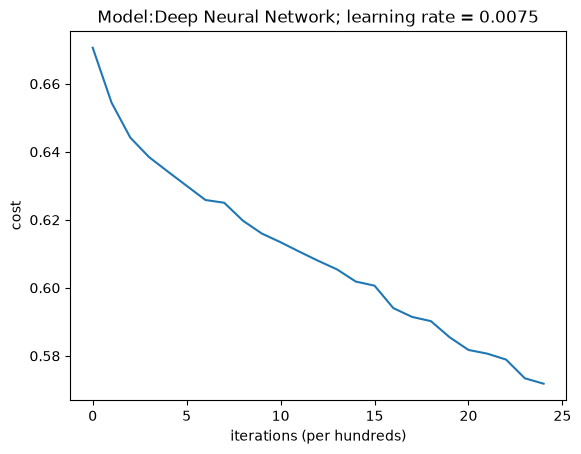

In [201]:
import matplotlib.pyplot as plt
plot_costs(cost_deep, "Deep Neural Network", learning_rate)

In [188]:
layer_dims_deep = [input_features, 30, 1]

parameter_shallow, cost_shallow = dnn_model(X_train, Y_train, X_test, Y_test, layer_dims_deep, iteration, learning_rate,True)

Cost: 0.6664566905153884
Cost: 0.653754439300079
Cost: 0.6454216908224192
Cost: 0.6393151703905681
Cost: 0.6333592564225535
Cost: 0.628276828207738
Cost: 0.6238465716630179
Cost: 0.6200319204531786
Cost: 0.6162629389172097
Cost: 0.6134318920052672
Cost: 0.6101133059045745
Cost: 0.6067536418810093
Cost: 0.6041455090667792
Cost: 0.6005811227350999
Cost: 0.5967552792877797
Cost: 0.5943910831612486
Cost: 0.590881270417842
Cost: 0.5888594094527492
Cost: 0.5869722277177416
Cost: 0.5836998092375439
Cost: 0.5805272723539959
Cost: 0.5781581872456758
Cost: 0.5756288538808784
Cost: 0.5728286913575238
Cost: 0.5698092237852936
train_accuracy: 68.84447220487195%
test_accuracy: 63.173504695996044%


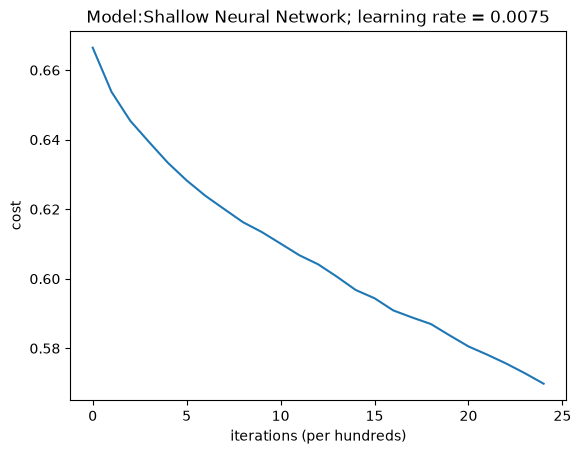

In [202]:
plot_costs(cost_shallow, "Shallow Neural Network", learning_rate)

In [192]:
layer_dims_deep = [input_features, 1]

parameter_logistic_regression, cost_logistic_regression = dnn_model(X_train, Y_train, X_test, Y_test, layer_dims_deep, iteration, learning_rate,True)

Cost: 2.2926639818992256
Cost: 2.173352140493441
Cost: 2.104987579385317
Cost: 2.057349855937839
Cost: 2.021686485394459
Cost: 1.9936647206468106
Cost: 1.9709029116885257
Cost: 1.9519543036301077
Cost: 1.9358605182213058
Cost: 1.9219480081588218
Cost: 1.9097275684543293
Cost: 1.8988372303876195
Cost: 1.8890055692918002
Cost: 1.880026616572469
Cost: 1.8717422618900326
Cost: 1.8640297558816512
Cost: 1.8567927577855308
Cost: 1.8499548706118571
Cost: 1.8434549330202592
Cost: 1.837243558602249
Cost: 1.8312805659010256
Cost: 1.825533048515677
Cost: 1.8199739085736188
Cost: 1.8145807285020996
Cost: 1.8093348921274188
train_accuracy: 52.91692692067458%
test_accuracy: 53.583786455758776%


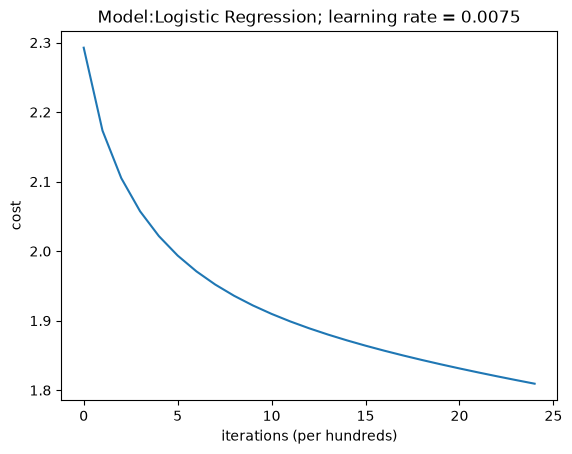

In [203]:
plot_costs(cost_logistic_regression, "Logistic Regression", learning_rate)

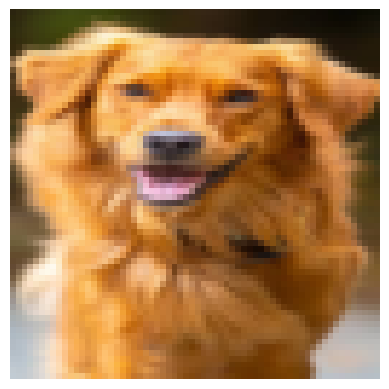

In [233]:
my_image = "cute_dog.jpeg"
fname = "../../test-dataset/images/" + my_image

img = Image.open(fname).convert("RGB").resize((SIZE, SIZE), Image.BILINEAR)
image = np.asarray(img, dtype=np.uint8)

plt.imshow(image)
plt.axis("off")

x_real_data = image.reshape(1, SIZE * SIZE * 3).T / 255.0

Logistic Regression predict it's a cats picture
Shallow Neural Network predict it's a cats picture
Deep Neural Network predict it's a cats picture


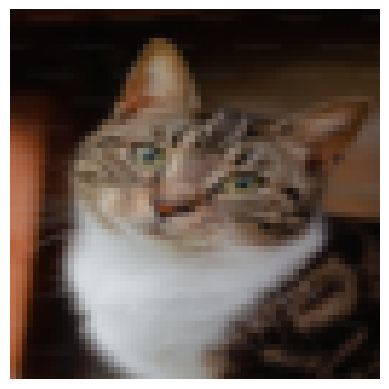

In [242]:
def get_label (prediction):
    label = np.squeeze(prediction)
    label_str =  CLASSES[label]
    return label_str


my_image = "cat_focus.png"
fname = "../../test-dataset/images/" + my_image

img = Image.open(fname).convert("RGB").resize((SIZE, SIZE), Image.BILINEAR)
image = np.asarray(img, dtype=np.uint8)

plt.imshow(image)
plt.axis("off")

x_real_data = image.reshape(1, SIZE * SIZE * 3).T / 255.0



logistic_prediction = classify(x_real_data, parameter_logistic_regression)
print(f"Logistic Regression predict it's a {get_label(logistic_prediction)} picture")


shallow_prediction = classify(x_real_data, parameter_shallow)
print(f"Shallow Neural Network predict it's a {get_label(shallow_prediction)} picture")


deep_prediction = classify(x_real_data, parameter_deep)
print(f"Deep Neural Network predict it's a {get_label(deep_prediction)} picture")
